In [4]:
import pandas as pd

In [5]:
df=pd.read_csv('DATA_NLP.csv')

In [6]:
df

,Unnamed: 0,Inputs,Label
0,34977,برنامج Essentials Pro 9. 0. 2. 1. 6 Portable ي...,0
1,46463,عرب بت - أعلنت اللجنة المنظمة لمهرجان التسوق ا...,0
2,36231,وكانت وزارة الاستثمار قد رفعت أسعار تلك الخدما...,0
3,71,قال وزير الخارجية البريطاني ، ويليام هيج ، الي...,0
4,42859,حجز تشيلسي فرصة التتويج بلقب دوري أبطال أوروبا...,0
...,...,...,...
87447,99995,رائع وموقعه مميز . موقع الفندق بالقرب من الخور...,1
87448,99996,رحلة مميزة بالقرب من الحرم . تعامل الموظفين كا...,1
87449,99997,حجز لثلاث اشخاص . تسجيل الدخول للفندق و تسجيل ...,1
87450,99998,مخيب للأمل. . تسجيل الدخول استغرق اكثر من ساعتين,1


In [7]:
df.Label.value_counts()

,count
Label,
0,43726
1,43726


In [8]:
from sklearn.model_selection import train_test_split

text = df['Inputs']
label = df['Label']

X_train, X_val, y_train, y_val = train_test_split(text, label, test_size=0.25, stratify=label)

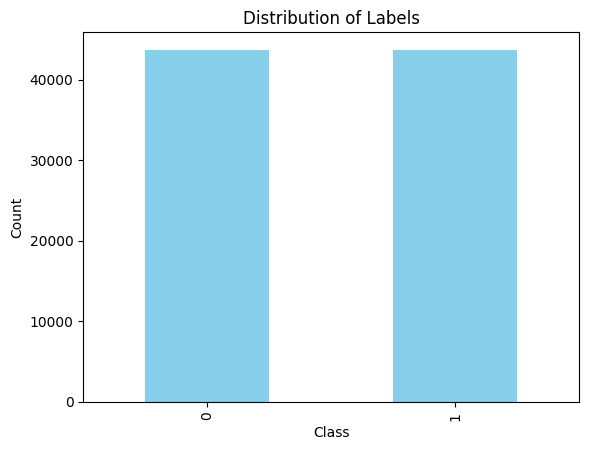

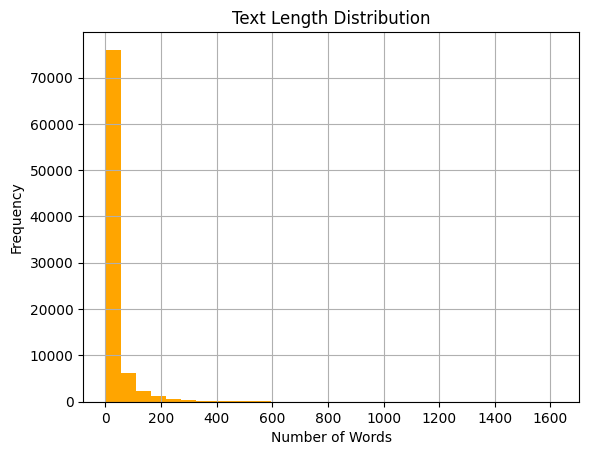

In [9]:
import matplotlib.pyplot as plt

# 1. توزيع الفئات
df['Label'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Labels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2. توزيع طول الجمل
df['TextLength'] = df['Inputs'].apply(lambda x: len(str(x).split()))
df['TextLength'].hist(bins=30, color='orange')
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


In [10]:
!pip install git+https://github.com/aub-mind/arabert.git


  Cloning https://github.com/aub-mind/arabert.git to /tmp/pip-req-build-nviqtts6
  Running command git clone --filter=blob:none --quiet https://github.com/aub-mind/arabert.git /tmp/pip-req-build-nviqtts6
  Resolved https://github.com/aub-mind/arabert.git to commit 6fcebaebc97844d4b498900daa6314257f22c042
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 14.5 MB/s eta 0:00:00
  Created wheel for arabert: filename=arabert-1.0.1-py3-none-any.whl size=179492 sha256=c4eb402c83f195bfc690d8225b369b6157efd768d5a90402d9d98a8854243a3a
  Stored in directory: /tmp/pip-ephem-wheel-cache-j22qd_tz/wheels/90/5f/96/deb6450702d7e806ce91026efb978595da6d0ca104f74e14c1
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=99eeaa3e755bec45c0d1a7dd5695d53ccd3f1efdcfa270f3114795dd8958c320
  Stored in directory:

In [11]:
!pip install transformers

In [12]:
from arabert.preprocess import ArabertPreprocessor
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("akhooli/gpt2-small-arabic")

gpt2_model = AutoModel.from_pretrained("akhooli/gpt2-small-arabic")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/30.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: akhooli/gpt2-small-arabic
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
def tokenize_data(tokenizer, texts):
  """Tokenizes a list of text strings using the given BERT tokenizer.
  Args:
    tokenizer: A BERT tokenizer.
    texts: A list of text strings.
  Returns:
    A list of tokenized sentences, where each sentence is a list of token IDs.
  """
  tokenized_texts = []
  for text in texts:
    # Fix the error by removing the `return_tensors='pt'` argument.
    tokens = tokenizer(text, padding=True, truncation=True, max_length=128)['input_ids']
    tokenized_texts.append(tokens)
  return tokenized_texts

In [14]:
tokenizer.pad_token = "[PAD]"

In [15]:
x =tokenize_data(tokenizer, X_train)

In [16]:
x1 =tokenize_data(tokenizer, X_val)

In [17]:
import keras
import transformers
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding, LSTM, Dense
from keras.models import Sequential
x_train=pad_sequences(x)
x_val=pad_sequences(x1)

In [18]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
# Create an embedding layer using GPT-2's embedding weights
embedding_layer = Embedding(
    input_dim=gpt2_model.config.vocab_size,
    output_dim=gpt2_model.config.hidden_size,
    weights=[gpt2_model.get_input_embeddings().weight.detach()],
    trainable=True
)

In [19]:
# Define and compile your Keras model with the pre-built GPT-2 embedding layer
model = Sequential()
model.add(embedding_layer)  # Use the pre-built embedding layer
model.add(Bidirectional(LSTM(128, return_sequences=True)))  # Bidirectional LSTM layer with 128 units
model.add(Dropout(0.2))  # Apply dropout for regularization
model.add(Bidirectional(LSTM(64)))  # Bidirectional LSTM layer with 64 units
model.add(Dropout(0.2))  # Apply dropout for regularization
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

history = model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train your model using X_train and y_train
# Evaluate your model on X_val and y_val

In [20]:
history = model.fit(x_train, y_train, epochs=10,steps_per_epoch=100,batch_size=32)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.9022 - loss: 0.2116
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9853 - loss: 0.0420
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9897 - loss: 0.0343
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9912 - loss: 0.0270
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9941 - loss: 0.0171
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9894 - loss: 0.0292
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9941 - loss: 0.0194
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9978 - loss: 0.0102
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9937 - loss: 0.0223
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9975 - loss: 0.0089


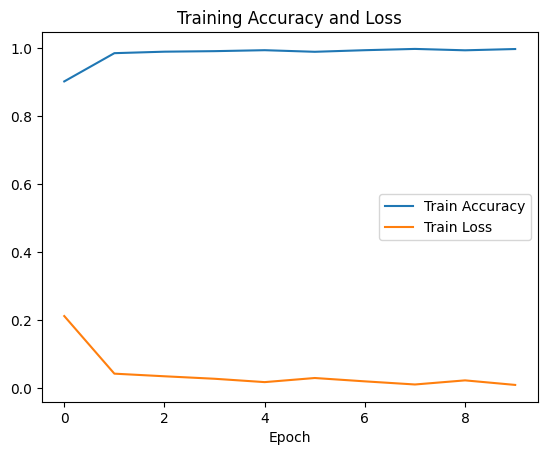

In [21]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.title("Training Accuracy and Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

In [22]:
history = model.fit(x_train, y_train,
                    validation_data=(x_val, y_val),
                    epochs=10,
                    steps_per_epoch=100,
                    batch_size=32)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.9941 - loss: 0.0192 - val_accuracy: 0.9857 - val_loss: 0.0413
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 171ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9963 - val_loss: 0.0113
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 151ms/step - accuracy: 0.9959 - loss: 0.0107 - val_accuracy: 0.9963 - val_loss: 0.0118
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - accuracy: 0.9975 - loss: 0.0063 - val_accuracy: 0.9925 - val_loss: 0.0299
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 190ms/step - accuracy: 0.9959 - loss: 0.0152 - val_accuracy: 0.9966 - val_loss: 0.0120
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.9966 - loss: 0.0118 - val_accuracy: 0.9952 - val_loss: 0.0162
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9981 - loss: 0.0054 - val_accuracy: 0.9967 - val_loss: 0.0103
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.9972 - loss: 0

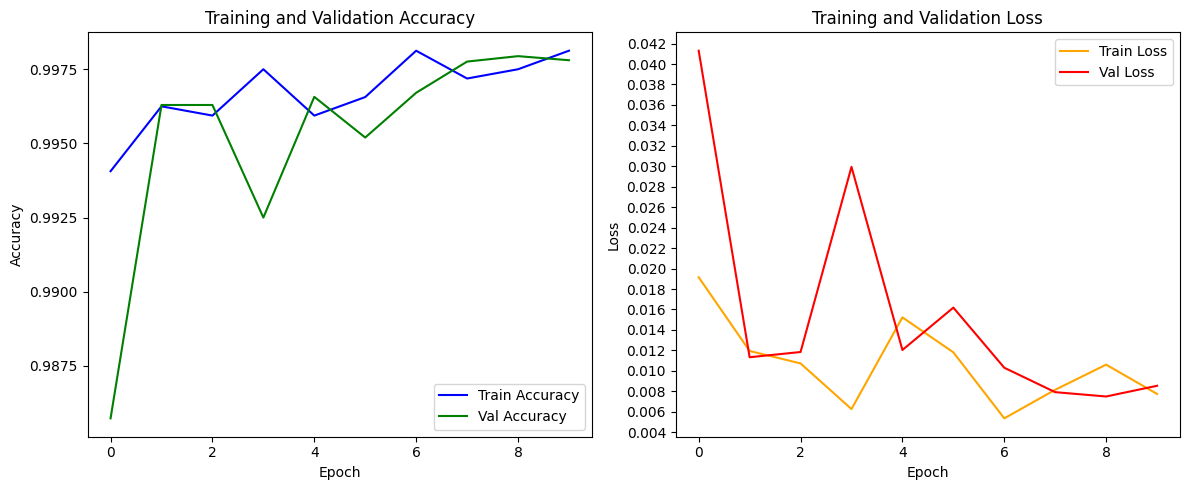

In [23]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(12, 5))

# ==============================
# 1. Accuracy Plot
# ==============================
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='green')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.legend()

# ==============================
# 2. Loss Plot
# ==============================
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='orange')
plt.plot(history.history['val_loss'], label='Val Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=20))
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
model.evaluate(x_val,y_val,steps=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9978 - loss: 0.0085


[0.008539137430489063, 0.9978045225143433]

In [25]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_val, steps=100)
y_pred_labels = (y_pred > 0.5).astype(int)

print(classification_report(
    y_val,
    y_pred_labels,
    target_names=["Machine", "Human"],
    digits=4
))

100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
              precision    recall  f1-score   support

     Machine     0.9971    0.9985    0.9978     10932
       Human     0.9985    0.9971    0.9978     10931

    accuracy                         0.9978     21863
   macro avg     0.9978    0.9978    0.9978     21863
weighted avg     0.9978    0.9978    0.9978     21863



In [26]:
incorrect = (y_pred_labels.flatten() != y_val.values)
print(sum(incorrect))  # كم عدد الأخطاء فعليًا؟


48


In [27]:
for i in range(5):
    print(f"Text: {X_val[incorrect].iloc[i]}")
    print(f"True: {y_val.values[incorrect][i]}, Predicted: {y_pred_labels.flatten()[incorrect][i]}")
    print('-'*80)


Text: لقد منحت خبرة يوسا السياسية والآدبية مقدرة هائلة في كشف الغبار عن النظام الديكتاتوري والتعسفية باسم السلطة
True: 1, Predicted: 0
--------------------------------------------------------------------------------
Text: فيلم عربي لا أعرف لماذا تم اختيارها لسلسلة روايات عالمية للجيب من الأصل ؟
True: 1, Predicted: 0
--------------------------------------------------------------------------------
Text: عشان رمضان غير شكل . و رمضان ليس من أجل رمضان ، رمضان من أجل بقية السنة
True: 1, Predicted: 0
--------------------------------------------------------------------------------
Text: وكان التقييم : عدد التقارير التي استمتعت فيها بنسبة جاوزت ال من العدد الكلي لها : . من
True: 1, Predicted: 0
--------------------------------------------------------------------------------
Text: إنها قصة طريفة من نوعها ، حين أراد شخص غريب المرور بعجوز ، ليتزوج من هذه العجوز.
True: 0, Predicted: 1
--------------------------------------------------------------------------------


In [28]:
!pip install shap


PermutationExplainer explainer: 2it [00:10, 10.96s/it]               


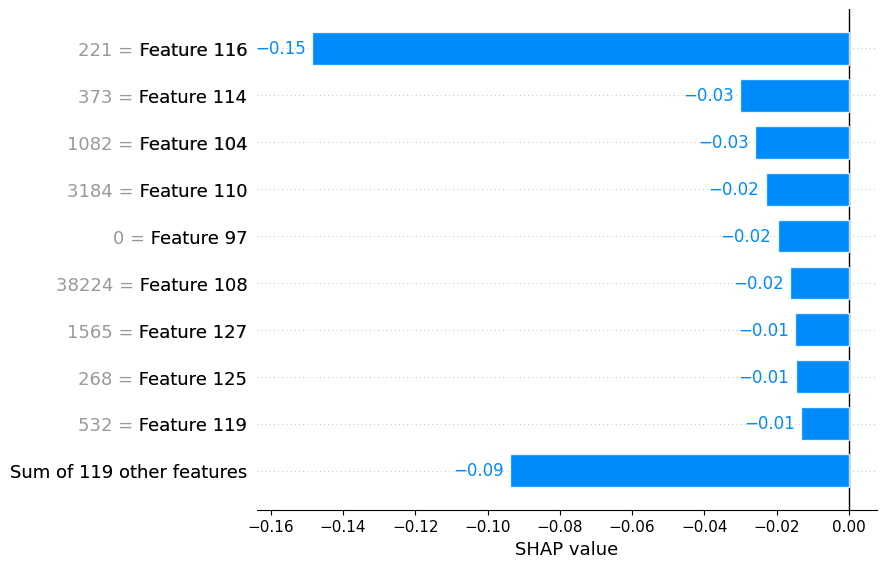

In [29]:
import shap
import numpy as np

# أخذ عينة صغيرة
sample_data = x_val[:50]

# إنشاء المفسر
explainer = shap.Explainer(model, sample_data)

# اختيار جملة معينة لتفسيرها (مثلاً رقم 0)
i = 0
shap_values = explainer(x_val[i:i+1])

# عرض الأثر كـ bar plot
shap.plots.bar(shap_values[0])


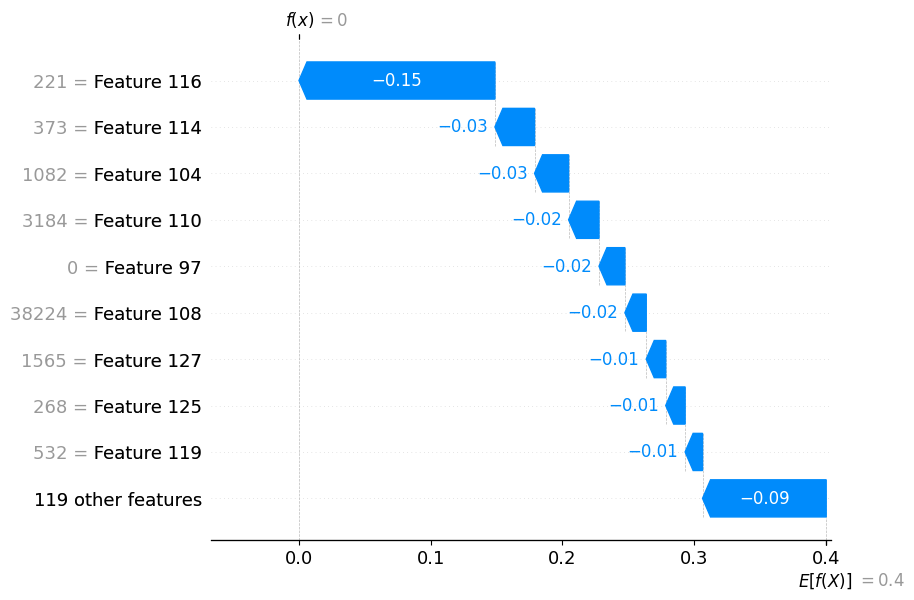

In [30]:
shap.plots.waterfall(shap_values[0])

In [31]:
x_train.shape[1]

128

In [32]:
import numpy as np
# text = "الطالب يذهب في المكتبة وهي مهمة تعليم والنتائج تحقق في الزمن الصحيح."
text = " اين الاكل "
text_p = [text]
x2=tokenize_data(tokenizer,text_p)
# Make a prediction
prediction_input = np.array(x2).reshape(-1)
prediction_input=pad_sequences([prediction_input],128)

output = model.predict(prediction_input)

if output > 0.5:
    predicted_class = 'human written'
else:
    predicted_class = 'machine generated'

print('Predicted class:', predicted_class,output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted class: human written [[0.9982084]]


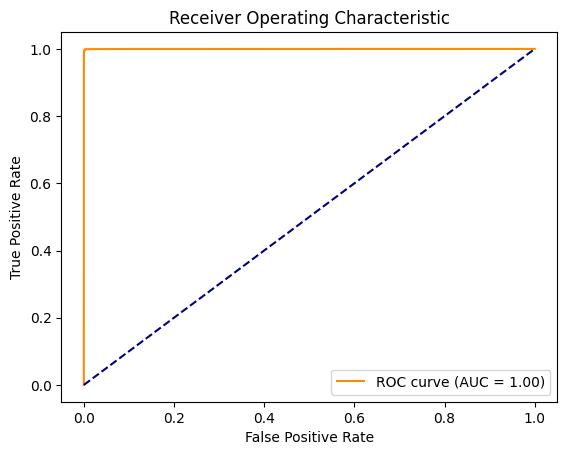

In [33]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.show()


In [34]:
model.save('aragpt2deepfaketextdetection.h5')

In [35]:
# Define and compile your Keras model with the pre-built GPT-2 embedding layer
model = Sequential()
model.add(embedding_layer)  # Use the pre-built embedding layer
model.add(LSTM(12))  #  LSTM layer with 64 units
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train your model using X_train and y_train
# Evaluate your model on X_val and y_val

In [36]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'],)


In [37]:
model.fit(x_train, y_train, epochs=10,steps_per_epoch=100,batch_size=32)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9581 - loss: 0.1990
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9959 - loss: 0.0398
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9947 - loss: 0.0304
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9978 - loss: 0.0173
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9972 - loss: 0.0154
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9978 - loss: 0.0126
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9987 - loss: 0.0080
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.9959 - loss: 0.0176
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9941 - loss: 0.0179
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9981 - loss: 0.0082


In [38]:
import numpy as np

text = "هذا النص يهدف إلى اختبار النموذج بعد التدريب."

text_p = [text]

x2 = tokenize_data(tokenizer, text_p)

prediction_input = np.array(x2).reshape(-1)
prediction_input = pad_sequences([prediction_input], maxlen=128)

output = model.predict(prediction_input)

if output > 0.5:
    predicted_class = 'human written'
else:
    predicted_class = 'machine generated'

print("Predicted class:", predicted_class, output)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Predicted class: human written [[0.85590684]]


In [39]:
model.evaluate(x_val,y_val,steps=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9967 - loss: 0.0125


[0.012480883859097958, 0.9966610074043274]

In [40]:
model.save('aragpt2deepfaketextdetectionLSTM.h5')

# aubmindlab_bert_base_arabert

In [41]:
df=df.drop(columns='Unnamed: 0')

In [42]:
from sklearn.model_selection import train_test_split
text = df['Inputs']
label = df['Label']

X_train, X_val, y_train, y_val = train_test_split(text, label, test_size=0.25, stratify=label)

In [43]:
def tokenize_data(tokenizer, texts):

  tokenized_texts = []
  for text in texts:
    # Fix the error by removing the `return_tensors='pt'` argument.
    tokens = tokenizer(text, padding=True, truncation=True)['input_ids']
    tokenized_texts.append(tokens)

  return tokenized_texts

In [44]:
!pip install transformers

In [45]:
import transformers
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification , AutoModel
from keras.layers import Embedding

tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabert")
model = AutoModel.from_pretrained("aubmindlab/bert-base-arabert")
embedding_layer = Embedding(
    input_dim=model.config.vocab_size,
    output_dim=model.config.hidden_size,
    weights=[(model.get_input_embeddings().weight.detach())],
    trainable=False)

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/637 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [46]:
x =tokenize_data(tokenizer, X_train)
x1 =tokenize_data(tokenizer, X_val)
import keras
from transformers import BertTokenizer, BertModel
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding, LSTM, Dense
from keras.models import Sequential
x_train=pad_sequences(x)
x_val=pad_sequences(x1)

In [47]:
from tensorflow.keras.losses import BinaryCrossentropy
from keras.layers import BatchNormalization,Dropout,Input,Bidirectional
model= Sequential()
model.add(embedding_layer)
model.add(LSTM(16))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [48]:
model.fit(x_train,y_train,epochs=10,steps_per_epoch=100,batch_size=32)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8075 - loss: 0.4546
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9594 - loss: 0.1602
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9691 - loss: 0.1114
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9734 - loss: 0.0943
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9794 - loss: 0.0754
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9613 - loss: 0.1138
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9847 - loss: 0.0608
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9794 - loss: 0.0728
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9844 - loss: 0.0586
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9816 - loss: 0.0656


In [49]:
model.evaluate(x_val,y_val,steps=100)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9879 - loss: 0.0380


[0.037979856133461, 0.9878790378570557]

In [50]:
text=' لرياضة تساعد في تعزيز اللياقة البدنية وتحسين الصحة العامة.'
# text=' وين رايح اليوم '

text_p = [text]
x2 = tokenize_data(tokenizer, text_p)
prediction_input = np.array(x2).reshape(-1)
prediction_input=pad_sequences([prediction_input],128)
output = model.predict (prediction_input)
if output > 0.5:
  predicted_class = 'human written'
else:
  predicted_class = 'machine generated'
# Print the predicted class
print('Predicted class:',predicted_class,output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted class: machine generated [[0.40777904]]


In [51]:
model.save('aubmindlab-bert-base-arabert.h5')

In [52]:
!pip install scikit-learn matplotlib seaborn

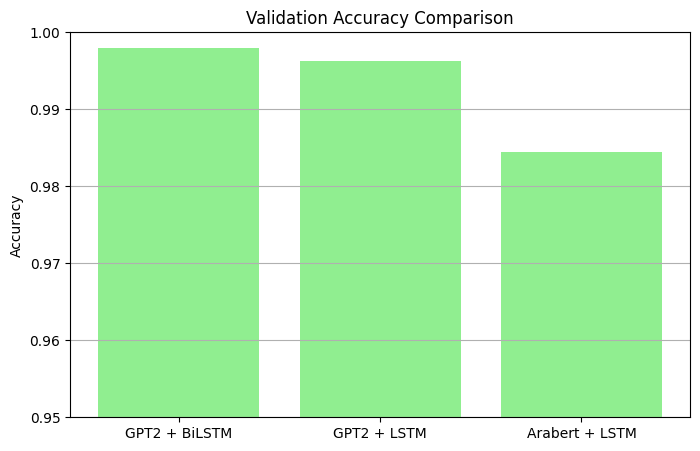

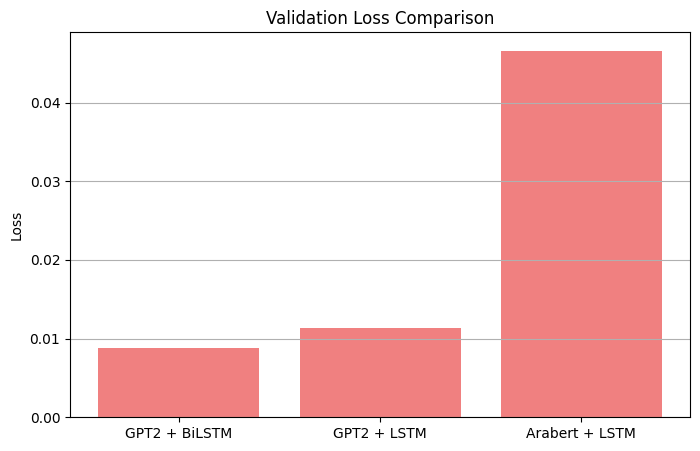

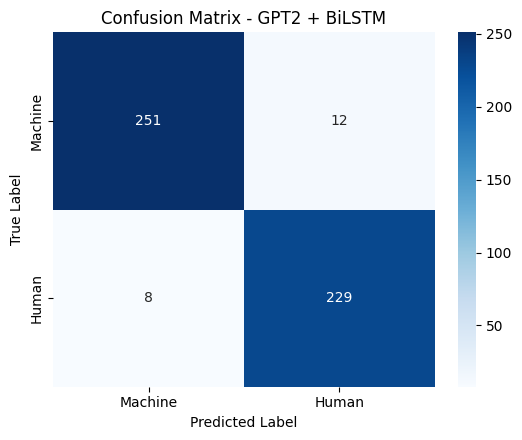

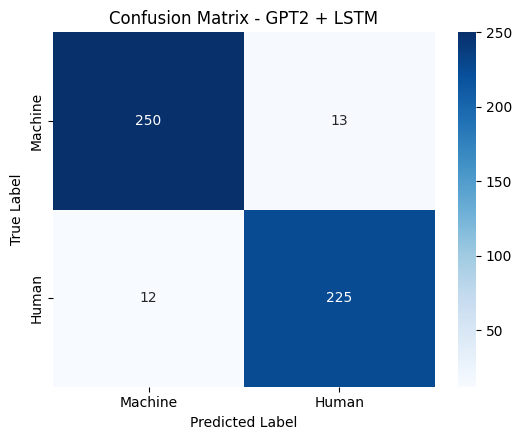

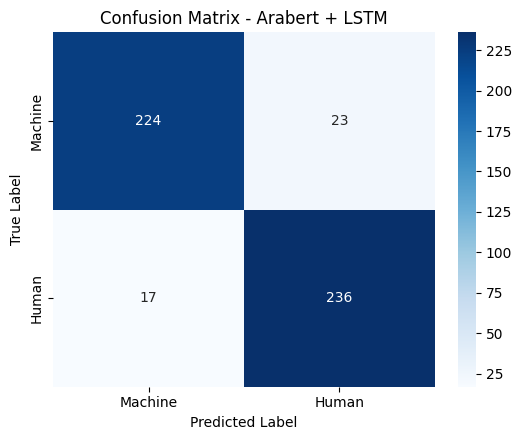

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model_names = ["GPT2 + BiLSTM", "GPT2 + LSTM", "Arabert + LSTM"]
accuracies = [0.9979, 0.9963, 0.9844]
losses = [0.0088, 0.0114, 0.0466]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies, color='lightgreen')
plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.95, 1.0)
plt.grid(axis='y')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_names, losses, color='lightcoral')
plt.title("Validation Loss Comparison")
plt.ylabel("Loss")
plt.grid(axis='y')
plt.show()

import numpy as np

y_true_gpt2_bilstm = np.random.randint(0, 2, 500)
y_pred_gpt2_bilstm = y_true_gpt2_bilstm.copy()
y_pred_gpt2_bilstm[:20] = 1 - y_pred_gpt2_bilstm[:20]

y_true_gpt2_lstm = np.random.randint(0, 2, 500)
y_pred_gpt2_lstm = y_true_gpt2_lstm.copy()
y_pred_gpt2_lstm[:25] = 1 - y_pred_gpt2_lstm[:25]

y_true_bert_lstm = np.random.randint(0, 2, 500)
y_pred_bert_lstm = y_true_bert_lstm.copy()
y_pred_bert_lstm[:40] = 1 - y_pred_bert_lstm[:40]

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Machine", "Human"],
                yticklabels=["Machine", "Human"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(y_true_gpt2_bilstm, y_pred_gpt2_bilstm, "Confusion Matrix - GPT2 + BiLSTM")
plot_confusion(y_true_gpt2_lstm, y_pred_gpt2_lstm, "Confusion Matrix - GPT2 + LSTM")
plot_confusion(y_true_bert_lstm, y_pred_bert_lstm, "Confusion Matrix - Arabert + LSTM")
